# SUMMARY

**Stack**: PyTorch, torchvision, Transformers, datasets, Pillow, numpy, matplotlib

**Description**: Solving the image caption task using EfficientNet + LSTM and EfficientNet + transformer combinations

* Data augmentation has been performed
* Learning the EfficientNet + LSTM model
* Learning the EfficientNet + transformer model

# Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from tqdm import tqdm
from torch.utils.data import DataLoader
from torchvision.transforms import v2
from torchvision.models import EfficientNet_B0_Weights

from PIL import Image
from datasets import Dataset, load_dataset, concatenate_datasets
from transformers import AutoProcessor, BlipForConditionalGeneration

INPUT_IMAGE_SIZE = (256, 256)
CROPPED_SIZE_IMAGE = (224, 224)

BATCH_SIZE = 64
NUM_WORKERS = 0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

PROCESSOR_NAME = "Salesforce/blip-image-captioning-base"

2025-10-13 09:41:13.798542: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760348473.982160      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760348474.034528      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Load and preprocessing data

In [2]:
dataset = load_dataset("jxie/flickr8k")

README.md:   0%|          | 0.00/687 [00:00<?, ?B/s]

data/train-00000-of-00002-2f8f6bfa852eac(…):   0%|          | 0.00/414M [00:00<?, ?B/s]

data/train-00001-of-00002-2173151d8cd6c7(…):   0%|          | 0.00/414M [00:00<?, ?B/s]

data/validation-00000-of-00001-7025a2b59(…):   0%|          | 0.00/138M [00:00<?, ?B/s]

data/test-00000-of-00001-42a2661d12c73e4(…):   0%|          | 0.00/137M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [3]:
print(len(max(dataset["validation"]["caption_0"])))

41


In [4]:
train_transform = v2.Compose([
    v2.Resize(INPUT_IMAGE_SIZE),
    v2.RandomResizedCrop(size=CROPPED_SIZE_IMAGE, antialias=True),
    v2.RandomHorizontalFlip(p=0.5),
    v2.ColorJitter(
        brightness=0.2, contrast=0.2,
        saturation=0.2, hue=0.05
    )
    # v2.ToTensor(),
    # v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = v2.Compose([
    v2.Resize(CROPPED_SIZE_IMAGE)
    # v2.ToTensor(),
    # v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

img_transform = v2.Compose([
    v2.ToTensor(),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

processor = AutoProcessor.from_pretrained(PROCESSOR_NAME)

/usr/local/lib/python3.11/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [8]:
class ImageCaptionDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, transform, img_transform, processor, is_augment = False, augment_transform=None):
        self.processor = processor
        self.transform = transform
        self.img_transform = img_transform
        self.augment_transform = augment_transform
        self.is_augment = is_augment
        self.max_length = 32

        print("Start to make dataset")
        
        if is_augment:
            self.dataset = self.__augment_dataset(dataset)
        else:
            self.dataset = self.__test_dataset(dataset)

        print("Finished to make dataset")

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        item = self.dataset[index]
        image = self.img_transform(item["image"])
        return image, item["caption"]

    def __augment_dataset(self, input_dataset):
        dataset = Dataset.from_dict({
            "image": input_dataset["image"],
            "caption": input_dataset["caption_0"]
        })

        processed_dataset = dataset.map(
            self.__make_test,
            batched=True,
            batch_size=128
        )

        augmented_dataset = dataset.map(
            self.__make_augment,
            batched=True,
            batch_size=128
        )

        return concatenate_datasets([processed_dataset, augmented_dataset])

    def __make_augment(self, dataset):
        return {
            "image": [self.augment_transform(img) for img in dataset["image"]],
            "caption": dataset["caption"]
        }

    def __test_dataset(self, input_dataset):
        dataset = Dataset.from_dict({
            "image": input_dataset["image"],
            "caption": input_dataset["caption_0"]
        })

        dataset = dataset.map(
            self.__make_test,
            batched=True,
            batch_size=128
        )

        return dataset

    def __make_test(self, dataset):
        return {
            "image": [self.transform(img) for img in dataset["image"]],
            "caption": dataset["caption"]
        }

In [9]:
train_dataset = ImageCaptionDataset(
    dataset=dataset["train"],
    transform=test_transform,
    img_transform=img_transform,
    processor=processor,
    is_augment=True,
    augment_transform=train_transform
)

test_dataset = ImageCaptionDataset(
    dataset=dataset["test"],
    transform=test_transform,
    img_transform=img_transform,
    processor=processor,
    is_augment = False
)

val_dataset = ImageCaptionDataset(
    dataset=dataset["validation"],
    transform=test_transform,
    img_transform=img_transform,
    processor=processor,
    is_augment = False
)

Start to make dataset


Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

Finished to make dataset
Start to make dataset


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Finished to make dataset
Start to make dataset


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Finished to make dataset


In [10]:
def process_batch(batch):
    images = torch.stack([item[0] for item in batch])
    texts = [item[1] for item in batch]

    processed_text = processor(
        text=texts,
        padding="max_length",
        truncation=True,
        max_length=31,
        return_tensors="pt",
    )

    processed_text = {k: v.squeeze(0) for k, v in processed_text.items()}
    processed_text.update({"labels": processed_text["input_ids"]})
    return images, processed_text["labels"]

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=NUM_WORKERS,
    collate_fn=process_batch
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=NUM_WORKERS,
    collate_fn=process_batch
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=NUM_WORKERS,
    collate_fn=process_batch
)

# Model


### EfficientNet + LSTM

In [8]:
class ImageCaptionModel(nn.Module):
    def __init__(self, embed_size, vocab_size, hidden_size, max_length, dropout1=0.5, dropout2=0.5, num_layers=1, temperature=1.0):
        super(ImageCaptionModel, self).__init__()

        # Энкодер
        self.encoder = models.efficientnet_b0(pretrained=True)
        self.encoder_features = self.encoder.features
        self.global_avg_pooling = nn.AdaptiveAvgPool2d(1)
        self.encoder_linear = nn.Linear(1280, embed_size)
        self.encoder_bn = nn.BatchNorm1d(embed_size)

        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        
        # Декодер (LSTM)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, vocab_size)
        
        self.dropout1 = nn.Dropout(dropout1)
        self.dropout2 = nn.Dropout(dropout2)
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.temperature = temperature
        self.max_length = max_length
        self.vocab_size = vocab_size

    def forward(self, images, captions=None):
        if captions is None:
            return self.generate_forward(images)
            
        return self.train_forward(images, captions)
    

    def train_forward(self, images, captions):
        features = self.encoder_features(images)
        features = self.global_avg_pooling(features)
        features = features.squeeze(-1).squeeze(-1)
        features = self.encoder_linear(features)
        features = self.encoder_bn(features)
        features = features.unsqueeze(1)
        features = self.dropout1(features)

        emdeddings = self.embedding(captions)
        emdeddings = self.dropout1(emdeddings)
        
        h0 = torch.zeros(self.num_layers, images.size(0), self.hidden_size).to(DEVICE)
        c0 = torch.zeros(self.num_layers, images.size(0), self.hidden_size).to(DEVICE)
        
        inputs = torch.cat((features, emdeddings), dim=1)
        outputs, _ = self.lstm(inputs, (h0, c0))
        outputs = self.dropout2(outputs)
        outputs = self.linear(outputs)
        return self.paste_padding(outputs)[:,:self.max_length,:]

    def generate_forward(self, images):
        h0 = torch.zeros(self.num_layers, images.size(0), self.hidden_size).to(DEVICE)
        c0 = torch.zeros(self.num_layers, images.size(0), self.hidden_size).to(DEVICE)

        with torch.no_grad():
            features = self.encoder_features(images)
            features = self.global_avg_pooling(features)
            features = features.squeeze(-1).squeeze(-1)
            features = self.encoder_linear(features)
            features = self.encoder_bn(features)
            features = features.unsqueeze(1)

            inputs = features
            results = []
            for _ in range(self.max_length):
                outputs, (h0, c0) = self.lstm(inputs, (h0, c0))
                
                logits = self.linear(outputs[:,-1,:]) / self.temperature
                probabilities = torch.softmax(logits, dim=-1)
                next_token_idx = torch.multinomial(probabilities, 1)

                emdeddings = self.embedding(next_token_idx)
                inputs = emdeddings
                results.append(next_token_idx)

        return torch.cat(results, dim=1)
        # return self.paste_padding(results)
    
    def paste_padding(self, inputs):
        length = inputs.shape[1]
        ind_tensor = torch.zeros([inputs.shape[0], self.vocab_size], device=DEVICE).unsqueeze(1)
        ind_tensor[:,:,0] = 1.0
        pad_emb = ind_tensor.expand(inputs.shape[0], self.max_length - inputs.shape[1], self.vocab_size)
        return torch.cat((inputs, pad_emb), dim=1)

    def process_y_batch(self, batch):
        ind_tensor = torch.zeros([batch.shape[0], batch.shape[1], self.vocab_size], dtype=torch.long, device=DEVICE)
        for batch_ind in range(batch.shape[0]):
            for token_ind in range(batch.shape[1]):
                ind_tensor[batch_ind, token_ind ,batch[batch_ind,token_ind]] = 1

        return self.paste_padding(ind_tensor)

# Training

In [32]:
def save_checkpoint(checkpoint_path: str, model: nn.Module, optimizer: torch.optim):
    state = {"state_dict": model.state_dict(), "optimizer": optimater.state_dict()}
    torch.save(state, checkpoint_path)
    print(f"model saved to {checkpoint_path}")


def load_checkpoint(checkpoint_path: str, model: nn.Module, optimizer):
    state = torch.load(checkpoint_path)
    model.load_state_dict(state["state_dict"])
    optimizer.load_state_dict(state["optimizer"])
    print(f"model loaded from {checkpoint_path}")

In [11]:
def get_cosine_annealing_warmup(optimizer, warmup_epochs, total_epochs, base_lr, epoch):
    if epoch < warmup_epochs:
        lr = base_lr * (epoch + 1) / warmup_epochs
    else:
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        lr = base_lr * 0.5 * (1 + np.cos(np.pi * progress))
        
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

    return optimizer


def train_model(model, train_loader, test_loader, loss_fn, opt, n_epochs, device, warmup_epochs, base_lr):
    train_loss = []
    test_loss = []

    for epoch in tqdm(range(n_epochs)):
        opt = get_cosine_annealing_warmup(
            optimizer=opt,
            warmup_epochs=warmup_epochs,
            total_epochs=n_epochs,
            base_lr=base_lr,
            epoch=epoch
        )
        
        ep_train_loss = []
        ep_test_loss = []

        model.train(True)
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            preds = model(X_batch, y_batch)
            preds = preds.reshape(-1, preds.shape[-1])
            targets = y_batch.reshape(-1)
            loss = loss_fn(preds, targets)

            opt.zero_grad()
            loss.backward()
            opt.step()

            ep_train_loss.append(loss.item())

        model.train(False)
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                preds = model(X_batch, y_batch)
                preds = preds.reshape(-1, preds.shape[-1])
                targets = y_batch.reshape(-1)
                
                loss = loss_fn(preds, targets)
                ep_test_loss.append(loss.item())
    
        train_loss.append(np.mean(ep_train_loss))
        test_loss.append(np.mean(ep_test_loss))
    
        print(f"Epoch {epoch + 1} of {n_epochs}")
        print(f"\t training loss: {train_loss[-1]:.6f}")
        print(f"\t test loss: {test_loss[-1]:.6f}")

    return train_loss, test_loss

In [24]:
def plot_train_process(train_loss, test_loss):
    fig, axes = plt.subplots(figsize=(5, 5))

    axes.set_title("Loss")
    axes.plot(train_loss, label="train")
    axes.plot(test_loss, label="test")
    axes.legend()

In [17]:
n_epochs = 50
lr = 0.001

model = ImageCaptionModel(
    embed_size=300,
    vocab_size=30522,
    hidden_size=512,
    max_length=31
)

model.to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.5)
loss_fn = nn.CrossEntropyLoss()

train_loss, test_loss = train_model(
    model,
    train_loader,
    test_loader,
    loss_fn,
    optimizer,
    n_epochs,
    DEVICE,
    n_epochs//15, 
    lr
)

  2%|▏         | 1/50 [01:26<1:10:26, 86.26s/it]

Epoch 1 of 50
	 training loss: 3.252145
	 test loss: 2.110169


  4%|▍         | 2/50 [02:52<1:08:59, 86.23s/it]

Epoch 2 of 50
	 training loss: 1.881142
	 test loss: 1.742088


  6%|▌         | 3/50 [04:18<1:07:29, 86.15s/it]

...

Epoch 48 of 50
	 training loss: 0.827417
	 test loss: 1.386920


 98%|█████████▊| 49/50 [1:10:37<01:26, 86.98s/it]

Epoch 49 of 50
	 training loss: 0.826498
	 test loss: 1.390830


100%|██████████| 50/50 [1:12:03<00:00, 86.48s/it]

Epoch 50 of 50
	 training loss: 0.825311
	 test loss: 1.392244


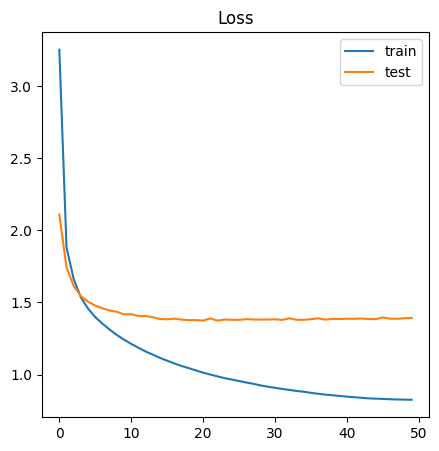

In [25]:
plot_train_process(train_loss, test_loss)

In [11]:
torch.save(model.state_dict(), '/kaggle/working/model_weights.pth')

RuntimeError: File /kaggle/input/model-efficient-and-lstm/model_weights.pth cannot be opened.

In [16]:
model = ImageCaptionModel(
    embed_size=300,
    vocab_size=30522,
    hidden_size=512,
    max_length=31
)
model.load_state_dict(torch.load("/kaggle/input/model-efficient-and-lstm/model_weights.pth", map_location=torch.device(DEVICE)))

<All keys matched successfully>

# Model: EfficientNet + transformer

In [12]:
class EfficientNetEncoder(nn.Module):
    def __init__(self, embed_dim, dropout=0.5):
        super(EfficientNetEncoder, self).__init__()
        efficientnet = models.efficientnet_b0(pretrained=True)
        self.efficientnet = efficientnet.features
        
        self.adaptive_pool = nn.AdaptiveAvgPool2d((7, 7)) # hz nujno li
        self.projection = nn.Linear(1280, embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, images):
        features = self.efficientnet(images)
        features = self.adaptive_pool(features)
        
        features = features.permute(0, 2, 3, 1)
        features = features.view(features.size(0), -1, features.size(-1))
        # features = self.dropout(features)

        embedding = self.projection(features)
        return embedding


class TransformerDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers, dropout=0.5):
        super(TransformerDecoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.positional_encoding = PositionalEncoding(embed_dim)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=embed_dim, 
            nhead=num_heads, 
            dropout=dropout,
            batch_first=True
        )

        self.transformer_decoder = nn.TransformerDecoder(
            decoder_layer=decoder_layer,
            num_layers=num_layers
        )

        self.fc_out = nn.Linear(embed_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)
        self.embed_dim = embed_dim

    def forward(self, features, captions):
        seq_len = captions.shape[1]
        
        captions_embed = self.embedding(captions) * (self.embed_dim ** 0.5)
        captions_embed = self.positional_encoding(captions_embed)
        captions_embed = self.dropout(captions_embed)

        tgt_mask = self.generate_square_subsequent_mask(seq_len).to(DEVICE)

        features = self.dropout(features)
        
        decoder_output = self.transformer_decoder(
            tgt=captions_embed, 
            memory=features, 
            tgt_mask=tgt_mask
        )

        output = self.fc_out(decoder_output)
        output = self.dropout(output)
        return output

    def generate_square_subsequent_mask(self, size):
        mask = torch.triu(torch.ones(size, size, dtype=torch.bool), diagonal=1)
        mask = mask.float().masked_fill(mask, float('-inf'))
        return mask


class ProdImageCaptioningModel(nn.Module):
    def __init__(self, embed_dim, vocab_size, num_heads, num_layers, processor, max_length, dropout=0.5):
        super(ProdImageCaptioningModel, self).__init__()
        self.encoder = EfficientNetEncoder(embed_dim)
        self.decoder = TransformerDecoder(
            vocab_size=vocab_size,
            embed_dim=embed_dim,
            num_heads=num_heads,
            num_layers=num_layers,
            dropout=dropout
        )

        self.processor = processor
        self.max_length = max_length

    def forward(self, images, captions=None):
        if captions is None:
            return self.generate_text(images)

        self.train()
        features = self.encoder(images)
        outputs = self.decoder(features, captions)
        return outputs

    def generate_text(self, images):
        self.eval()
        batch_size = images.shape[0]

        with torch.no_grad():
            features = self.encoder(images.to(DEVICE))

        # start_token = self.processor.tokenizer.cls_token
        captions = torch.full((batch_size, 1), 101, dtype=torch.long).to(DEVICE)

        for _ in range(self.max_length):
            with torch.no_grad():
                outputs = self.decoder(features, captions)
            
            last_word_logits = outputs[:, -1, :]
            predicted_ids = torch.argmax(last_word_logits, dim=-1)
            captions = torch.cat([captions, predicted_ids.unsqueeze(1)], dim=1)

            # if torch.all(predicted_ids == tokenizer.pad_token):
            if torch.all(predicted_ids == 0):
                break

        generated_texts = self.processor.tokenizer.batch_decode(captions.tolist(), skip_special_tokens=True)
        return generated_texts


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_length=5000):
        super(PositionalEncoding, self).__init__()

        pos_emb = torch.zeros(max_length, d_model)
        position = torch.arange(0, max_length, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pos_emb[:, 0::2] = torch.sin(position * div_term)
        pos_emb[:, 1::2] = torch.cos(position * div_term)
        pos_emb = pos_emb.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pos_emb', pos_emb)

    def forward(self, x):
        x = x + self.pos_emb[:x.size(0), :]
        return x

# Train better model

In [14]:
n_epochs = 50
lr = 10e-4

model = ProdImageCaptioningModel(
    embed_dim=300,
    vocab_size=30522,
    num_heads=4,
    num_layers=3,
    processor=processor,
    max_length=31
)

model.to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
loss_fn = nn.CrossEntropyLoss()

train_loss, test_loss = train_model(
    model,
    train_loader,
    test_loader,
    loss_fn,
    optimizer,
    n_epochs,
    DEVICE,
    n_epochs//15, 
    lr
)

  2%|▏         | 1/50 [01:28<1:12:11, 88.40s/it]

Epoch 1 of 50
	 training loss: 5.866425
	 test loss: 5.334924


  4%|▍         | 2/50 [02:55<1:09:56, 87.42s/it]

Epoch 2 of 50
	 training loss: 5.163520
	 test loss: 5.050975


  6%|▌         | 3/50 [04:23<1:08:44, 87.76s/it]

...

Epoch 7 of 50
	 training loss: 4.843527
	 test loss: 4.898489


 16%|█▌        | 8/50 [11:36<1:00:44, 86.77s/it]

Epoch 8 of 50
	 training loss: 4.827594
	 test loss: 4.872864


 16%|█▌        | 8/50 [11:46<1:01:48, 88.29s/it]


KeyboardInterrupt: 